# ST1504 CA2 Part A: CIFAR-10 Image Generation

## Objective

The objective of this project is to build and evaluate a generative deep learning model capable of generating CIFAR-10 images.

The CIFAR-10 dataset contains 60,000 colour images of size 32 × 32 pixels across 10 classes:

- Airplane
- Automobile
- Bird
- Cat
- Deer
- Dog
- Frog
- Horse
- Ship
- Truck

In this project, a Variational Autoencoder (VAE) / Generative Adversarial Network (GAN) will be trained to generate new images that resemble the original CIFAR-10 dataset.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.10.0


In [17]:
from tensorflow.keras.datasets import cifar10
import pickle
import numpy as np
import os

dataset_path = "cifar-10-batches-py"


def load_cifar_batch(file_path):
    with open(file_path, "rb") as file:
        batch = pickle.load(file, encoding="bytes")

    images = batch[b"data"]
    labels = np.array(batch[b"labels"])

    images = images.reshape(-1, 3, 32, 32)
    images = images.transpose(0, 2, 3, 1)

    return images, labels

In [18]:
x_train_batches = []
y_train_batches = []

for batch_number in range(1, 6):
    batch_path = os.path.join(
        dataset_path,
        f"data_batch_{batch_number}"
    )

    images, labels = load_cifar_batch(batch_path)

    x_train_batches.append(images)
    y_train_batches.append(labels)

x_train = np.concatenate(x_train_batches)
y_train = np.concatenate(y_train_batches)

x_test, y_test = load_cifar_batch(
    os.path.join(dataset_path, "test_batch")
)

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)

Training images: (50000, 32, 32, 3)
Training labels: (50000,)
Test images: (10000, 32, 32, 3)
Test labels: (10000,)


# EDA

In [19]:
# 1. Inspect the dataset structure
print("Training image shape:", x_train.shape)
print("Training label shape:", y_train.shape)

print("Image data type:", x_train.dtype)
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Training image shape: (50000, 32, 32, 3)
Training label shape: (50000,)
Image data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255


### Class distribution analysis

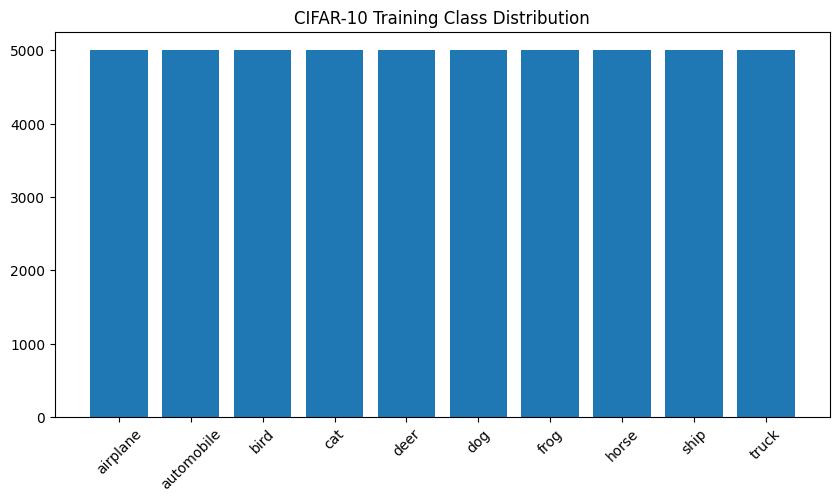

In [20]:
class_counts = np.bincount(y_train, minlength=10)
plt.figure(figsize=(10, 5))
plt.bar(class_names, class_counts)
plt.title("CIFAR-10 Training Class Distribution")
plt.xticks(rotation=45)
plt.show()

### Advanced Visualizations (Grid & Channels)

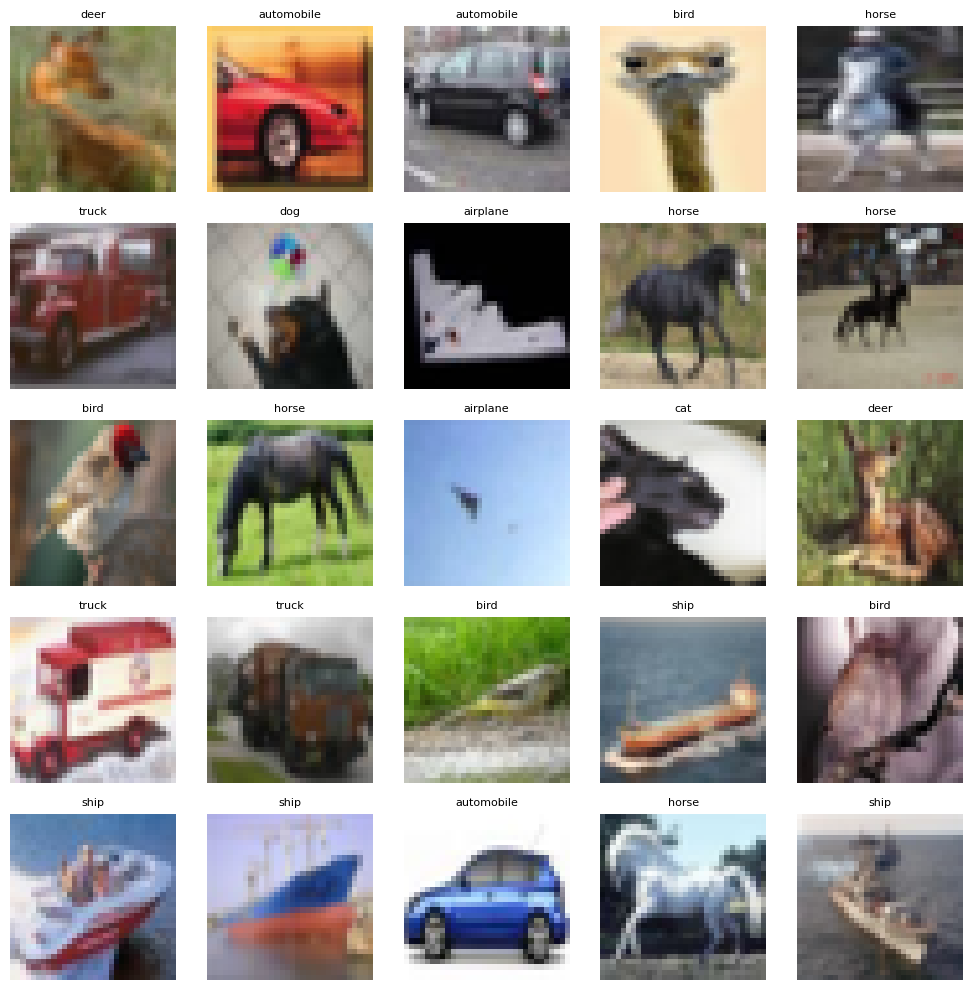

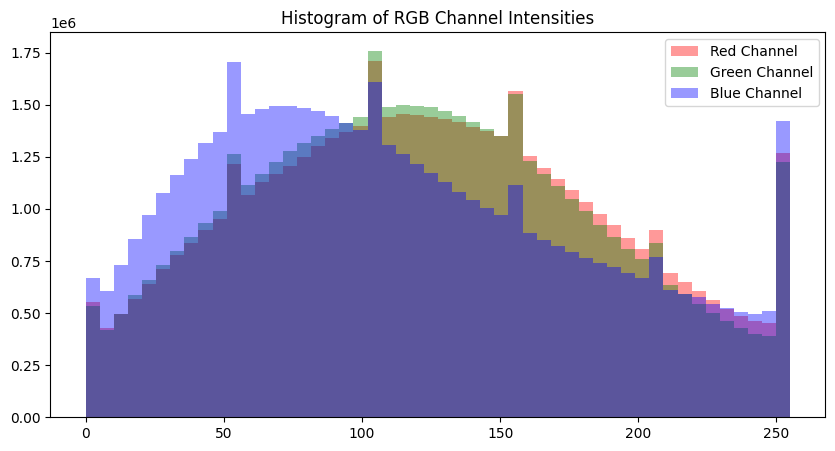

In [21]:
# 5x5 Grid
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
for i, ax in enumerate(axes.flatten()):
    idx = np.random.randint(0, x_train.shape[0])
    ax.imshow(x_train[idx])
    ax.axis('off')
    ax.set_title(class_names[y_train[idx]], fontsize=8)
plt.tight_layout()
plt.show()

# RGB Histograms
plt.figure(figsize=(10, 5))
for i, color in enumerate(['red', 'green', 'blue']):
    plt.hist(x_train[:, :, :, i].flatten(), bins=50, color=color, alpha=0.4, label=f'{color.capitalize()} Channel')
plt.title("Histogram of RGB Channel Intensities")
plt.legend()
plt.show()

### Data Cleaning & Normalization Checks

Missing values: 0
Infinite values: 0


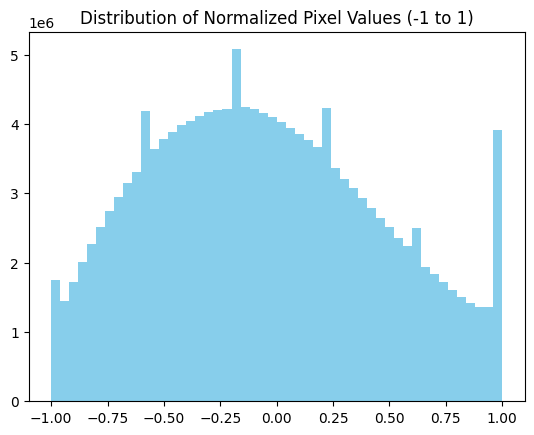

In [22]:
# Check for issues
print("Missing values:", np.isnan(x_train).sum())
print("Infinite values:", np.isinf(x_train).sum())

# Normalize and visualize
x_train_norm = (x_train.astype('float32') / 127.5) - 1
plt.hist(x_train_norm.flatten(), bins=50, color='skyblue')
plt.title("Distribution of Normalized Pixel Values (-1 to 1)")
plt.show()

### Variance Analysis (Blank/Low-Quality Images)

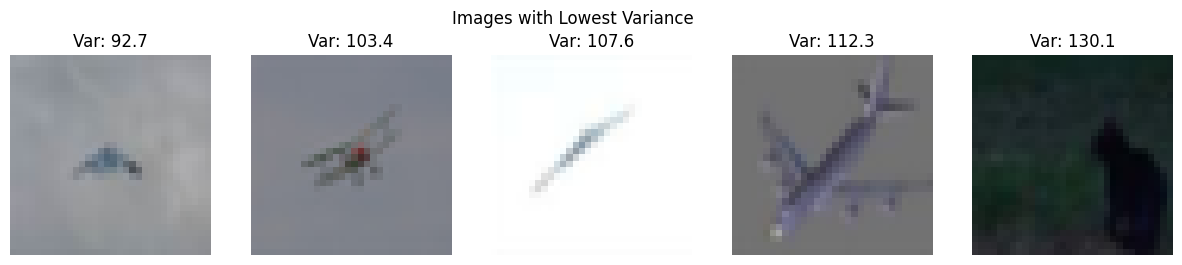

In [23]:
image_variances = x_train.var(axis=(1, 2, 3))
low_var_indices = np.argsort(image_variances)[:5]

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, idx in enumerate(low_var_indices):
    axes[i].imshow(x_train[idx])
    axes[i].set_title(f"Var: {image_variances[idx]:.1f}")
    axes[i].axis('off')
plt.suptitle("Images with Lowest Variance")
plt.show()

### Comparison (Train vs Test)

In [24]:
train_counts = np.bincount(y_train, minlength=10)
test_counts = np.bincount(y_test, minlength=10)
print("Training counts:", train_counts)
print("Test counts:", test_counts)

Training counts: [5000 5000 5000 5000 5000 5000 5000 5000 5000 5000]
Test counts: [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]


### Intra-Class Variance (Which classes are "harder"?)

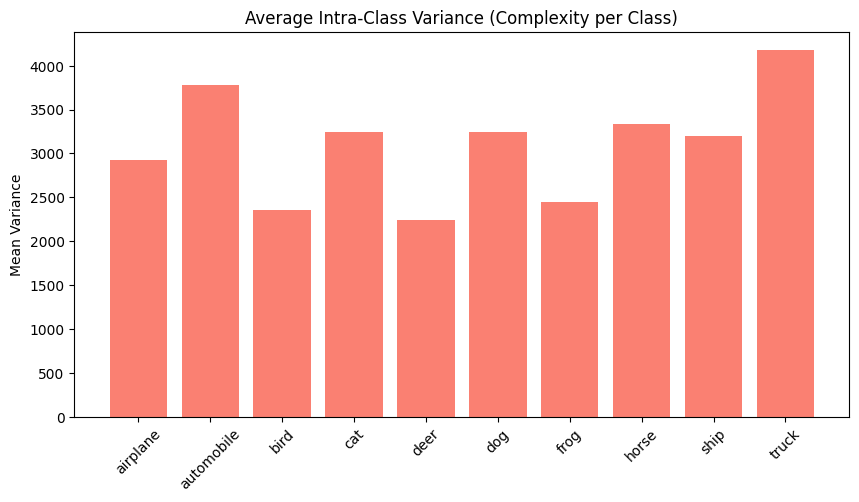

In [25]:
# Calculate variance for each image, then group by class
class_variances = []
for i in range(10):
    class_images = x_train[y_train == i]
    # Variance of each image, then mean of those variances
    avg_var = np.mean(np.var(class_images, axis=(1, 2, 3)))
    class_variances.append(avg_var)

plt.figure(figsize=(10, 5))
plt.bar(class_names, class_variances, color='salmon')
plt.title("Average Intra-Class Variance (Complexity per Class)")
plt.ylabel("Mean Variance")
plt.xticks(rotation=45)
plt.show()

### Mean Class Images

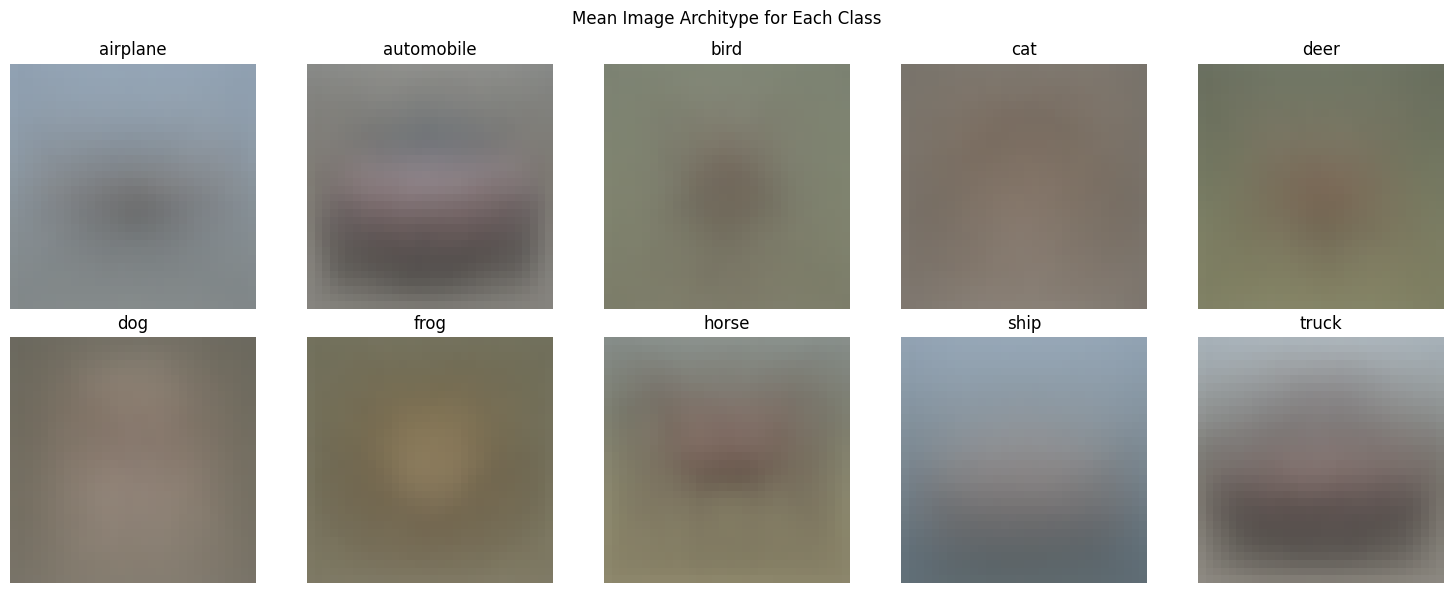

In [29]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    class_images = x_train[y_train == i]
    mean_img = np.mean(class_images, axis=0).astype('uint8')
    axes[i].imshow(mean_img)
    axes[i].set_title(class_names[i])
    axes[i].axis('off')

plt.suptitle("Mean Image Architype for Each Class")
plt.tight_layout()
plt.show()

### Grayscale Comparison (B&W vs Color)

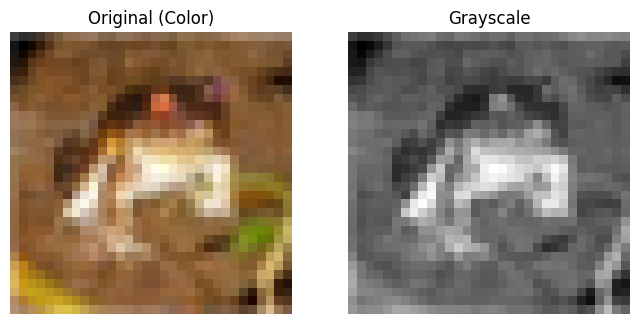

In [27]:
# Convert to grayscale by averaging channels
x_train_gray = np.mean(x_train, axis=3, keepdims=True)

# Compare shapes and visualize
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(x_train[0])
plt.title("Original (Color)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(x_train_gray[0].reshape(32, 32), cmap='gray')
plt.title("Grayscale")
plt.axis('off')
plt.show()

### Spatial Uniformity Check
check for malformed or corrupt images

In [28]:
# Check for consistent image shapes
shapes = [img.shape for img in x_train]
unique_shapes = np.unique(shapes, axis=0)

if len(unique_shapes) == 1:
    print(f"All images have a consistent shape of: {unique_shapes[0]}")
else:
    print("Warning: Dataset contains inconsistent image shapes:", unique_shapes)

All images have a consistent shape of: [32 32  3]
